<a href="https://colab.research.google.com/github/Rukmini83/Proyecto7/blob/main/pro_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import math as mth

data = pd.read_csv('logs_exp_us.csv', sep='\t')


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [32]:
data.columns = data.columns.str.lower()


In [33]:
data.sample(10)

,eventname,deviceidhash,eventtimestamp,expid
122015,MainScreenAppear,3662441162486667021,1564919305,247
342,CartScreenAppear,8835108532520342368,1564421902,246
139792,MainScreenAppear,5224056977998049474,1564952485,246
69184,CartScreenAppear,6658794173968727601,1564769680,246
124412,MainScreenAppear,6932517045703054087,1564922856,248
226548,PaymentScreenSuccessful,5767077514640514089,1565179241,248
6889,OffersScreenAppear,2108190255648110546,1564640964,248
108912,MainScreenAppear,106256020648490230,1564890185,246
32668,PaymentScreenSuccessful,7267296482767040558,1564682043,246
96495,CartScreenAppear,197027893265565660,1564844042,246


In [34]:
data.isnull().sum()

,0
eventname,0
deviceidhash,0
eventtimestamp,0
expid,0


In [35]:
data['	eventtimestamp'] = pd.to_timedelta(data['eventtimestamp'], unit='s')

print(data.head())


                 eventname         deviceidhash  eventtimestamp  expid  \
0         MainScreenAppear  4575588528974610257      1564029816    246   
1         MainScreenAppear  7416695313311560658      1564053102    246   
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248   
3         CartScreenAppear  3518123091307005509      1564054127    248   
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248   

     \teventtimestamp  
0 18102 days 04:43:36  
1 18102 days 11:11:42  
2 18102 days 11:28:47  
3 18102 days 11:28:47  
4 18102 days 11:48:42  


In [36]:
#'eventtimestamp' a formato legible

data['event_datetime'] = pd.to_datetime(data['eventtimestamp'], unit='s')
data['event_date'] = data['event_datetime'].dt.date
data['event_hour'] = data['event_datetime'].dt.hour

# Clasificar grupo
data['grupo'] = data['expid'].map({246: 'A_control', 247: 'A2_control', 248: 'B_prueba'})

In [37]:
data.head(10)

,eventname,deviceidhash,eventtimestamp,expid,\teventtimestamp,event_datetime,event_date,event_hour,grupo
0,MainScreenAppear,4575588528974610257,1564029816,246,18102 days 04:43:36,2019-07-25 04:43:36,2019-07-25,4,A_control
1,MainScreenAppear,7416695313311560658,1564053102,246,18102 days 11:11:42,2019-07-25 11:11:42,2019-07-25,11,A_control
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,18102 days 11:28:47,2019-07-25 11:28:47,2019-07-25,11,B_prueba
3,CartScreenAppear,3518123091307005509,1564054127,248,18102 days 11:28:47,2019-07-25 11:28:47,2019-07-25,11,B_prueba
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,18102 days 11:48:42,2019-07-25 11:48:42,2019-07-25,11,B_prueba
5,CartScreenAppear,6217807653094995999,1564055323,248,18102 days 11:48:43,2019-07-25 11:48:43,2019-07-25,11,B_prueba
6,OffersScreenAppear,8351860793733343758,1564066242,246,18102 days 14:50:42,2019-07-25 14:50:42,2019-07-25,14,A_control
7,MainScreenAppear,5682100281902512875,1564085677,246,18102 days 20:14:37,2019-07-25 20:14:37,2019-07-25,20,A_control
8,MainScreenAppear,1850981295691852772,1564086702,247,18102 days 20:31:42,2019-07-25 20:31:42,2019-07-25,20,A2_control
9,MainScreenAppear,5407636962369102641,1564112112,246,18103 days 03:35:12,2019-07-26 03:35:12,2019-07-26,3,A_control


In [38]:
#cuántos eventos hay por grupo:
eventos_por_grupo = data.groupby('grupo')['eventname'].count()
print(eventos_por_grupo)

grupo
A2_control    78075
A_control     80304
B_prueba      85747
Name: eventname, dtype: int64


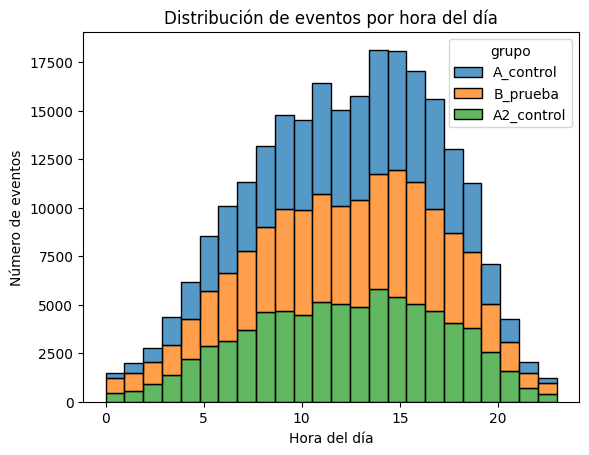

In [39]:

#Esto te ayuda a ver cuándo los usuarios interactúan más:
sns.histplot(data=data, x='event_hour', hue='grupo', multiple='stack', bins=24)
plt.title('Distribución de eventos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de eventos')
plt.show()

In [40]:
#ver cuántos eventos hizo cada usuario
eventos_por_usuario = data.groupby(['deviceidhash', 'grupo'])['eventname'].count().reset_index()
eventos_por_usuario.rename(columns={'eventname': 'num_eventos'}, inplace=True)
print(eventos_por_usuario.sample(10))

             deviceidhash       grupo  num_eventos
4770  5887503722462983075    B_prueba           15
544    724444571498081470    B_prueba           18
6270  7716166848354963661   A_control            9
2930  3666940454338004242   A_control           15
2333  2956083095170517025   A_control           34
6494  7966323257643346287    B_prueba          125
3310  4149035846939420063    B_prueba           31
6979  8534398700246007081  A2_control            9
3220  4031443559981204612    B_prueba            6
3656  4553790179120792653  A2_control            9


In [41]:
# Fecha mínima y máxima
fecha_min = data['event_datetime'].min()
fecha_max = data['event_datetime'].max()

print(f" Fecha mínima: {fecha_min}")
print(f" Fecha máxima: {fecha_max}")


 Fecha mínima: 2019-07-25 04:43:36
 Fecha máxima: 2019-08-07 21:15:17


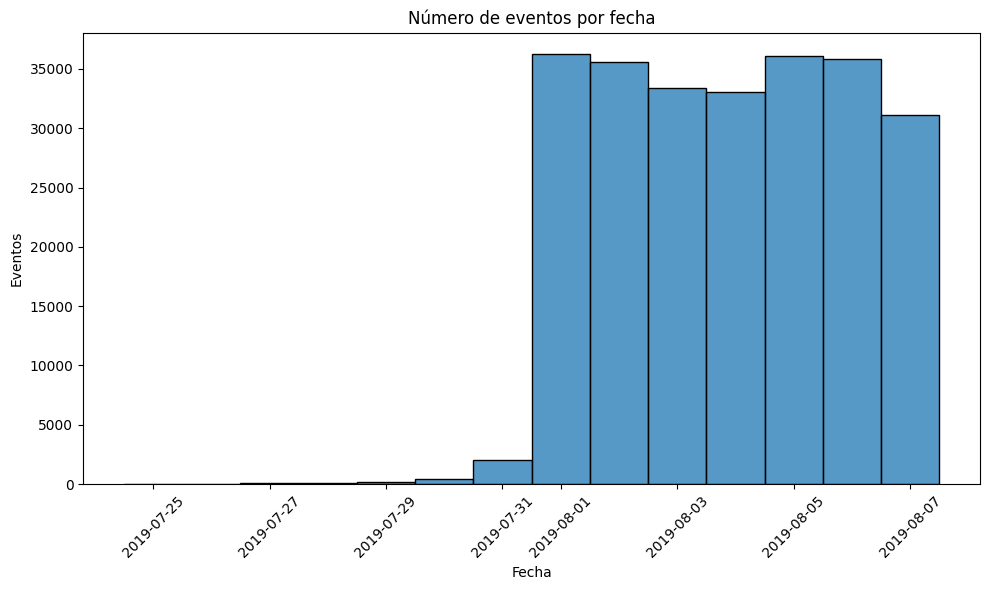

In [42]:


# Extraer solo la fecha
data['event_date'] = data['event_datetime'].dt.date

# Histograma por fecha
plt.figure(figsize=(10, 6))
sns.histplot(data= data, x='event_date', bins=len(data['event_date'].unique()), kde=False)
plt.xticks(rotation=45)
plt.title('Número de eventos por fecha')
plt.xlabel('Fecha')
plt.ylabel('Eventos')
plt.tight_layout()
plt.show()

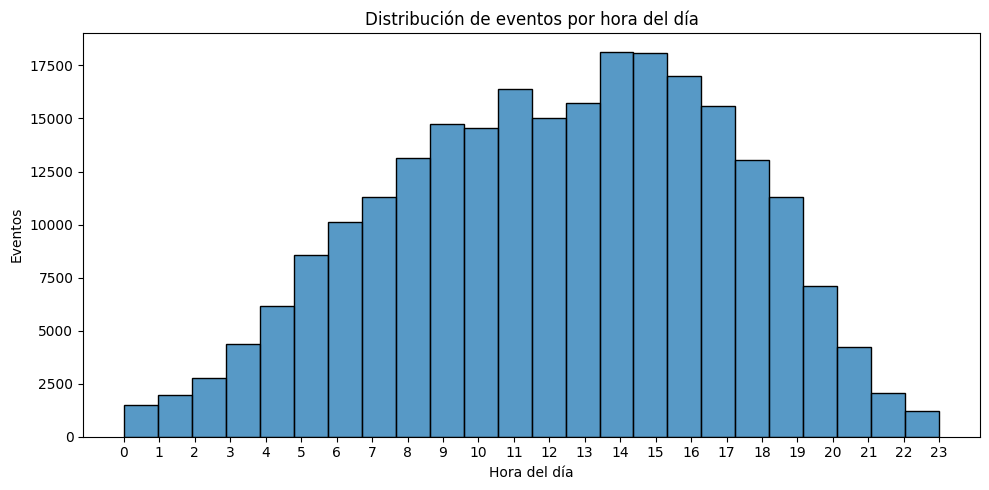

In [43]:
# Extraer hora
data['event_hour'] = data['event_datetime'].dt.hour

# Histograma por hora
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='event_hour', bins=24, kde=False)
plt.title('Distribución de eventos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Eventos')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [44]:
#Asegúrate de tener usuarios de los tres grupos experimentales.
grupos_presentes = data['expid'].unique()
usuarios_por_grupo = data.groupby('expid')['deviceidhash'].nunique()
print("Usuarios únicos por grupo:")
print(usuarios_por_grupo)
faltantes = set([246, 247, 248]) - set(grupos_presentes)
if faltantes:
    print(f" Faltan los siguientes grupos: {faltantes}")
else:
    print(" Todos los grupos están presentes.")

Usuarios únicos por grupo:
expid
246    2489
247    2520
248    2542
Name: deviceidhash, dtype: int64
 Todos los grupos están presentes.


In [45]:
# Contar frecuencia de cada tipo de evento
frecuencia_eventos = data['eventname'].value_counts()

# Mostrar ordenados de mayor a menor
print("Frecuencia de eventos:")
print(frecuencia_eventos)

Frecuencia de eventos:
eventname
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64


In [46]:
data['eventname'].unique()

array(['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear',
       'OffersScreenAppear', 'Tutorial'], dtype=object)

In [47]:
embudo = data['eventname'].unique()

# Usuarios únicos por evento
usuarios_por_evento = data.groupby('eventname')['deviceidhash'].nunique()

# Filtrar solo los eventos del embudo
usuarios_embudo = usuarios_por_evento[embudo]
# Proporción de usuarios que pasan de una etapa a la siguiente
proporciones = usuarios_embudo.shift(-1) / usuarios_embudo

# Crear DataFrame resumen
embudo_data = pd.DataFrame({
    'Usuarios únicos': usuarios_embudo,
    'Proporción a siguiente etapa': proporciones
})

etapa_mayor_perdida = embudo_data['Proporción a siguiente etapa'].idxmin()
print(f" Mayor pérdida ocurre entre: {etapa_mayor_perdida}")

 Mayor pérdida ocurre entre: OffersScreenAppear


In [48]:
#¿Qué porcentaje completa todo el embudo?
porcentaje_completo = usuarios_embudo['PaymentScreenSuccessful'] / usuarios_embudo['MainScreenAppear']
print(f"✅ Porcentaje que completa todo el viaje: {porcentaje_completo:.2%}")

✅ Porcentaje que completa todo el viaje: 47.68%


In [49]:
#¿Cuántos usuarios hay en cada grupo?
usuarios_por_grupo = data.groupby('expid')['deviceidhash'].nunique()
print(usuarios_por_grupo)

expid
246    2489
247    2520
248    2542
Name: deviceidhash, dtype: int64


In [50]:
#diferencia estadísticamente significativa entre las muestras 246 y 247



In [51]:
evento_top = data['eventname'].value_counts()
print(f"Evento más popular: {evento_top}")

Evento más popular: eventname
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64


In [52]:
data.head()

,eventname,deviceidhash,eventtimestamp,expid,\teventtimestamp,event_datetime,event_date,event_hour,grupo
0,MainScreenAppear,4575588528974610257,1564029816,246,18102 days 04:43:36,2019-07-25 04:43:36,2019-07-25,4,A_control
1,MainScreenAppear,7416695313311560658,1564053102,246,18102 days 11:11:42,2019-07-25 11:11:42,2019-07-25,11,A_control
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,18102 days 11:28:47,2019-07-25 11:28:47,2019-07-25,11,B_prueba
3,CartScreenAppear,3518123091307005509,1564054127,248,18102 days 11:28:47,2019-07-25 11:28:47,2019-07-25,11,B_prueba
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,18102 days 11:48:42,2019-07-25 11:48:42,2019-07-25,11,B_prueba


In [53]:
# Total de usuarios únicos en el dataset
total_usuarios = data['deviceidhash'].nunique()

# Usuarios únicos por evento
usuarios_por_evento = data.groupby('eventname')['deviceidhash'].nunique()

# Proporción de usuarios que realizaron cada evento
proporcion_por_evento = usuarios_por_evento / total_usuarios

# Crear DataFrame resumen
resumen_eventos = pd.DataFrame({
    'Usuarios únicos': usuarios_por_evento,
    'Proporción': proporcion_por_evento
})

# Ordenar por número de usuarios
resumen_eventos = resumen_eventos.sort_values(by='Usuarios únicos', ascending=False)

# Mostrar resultado
print(resumen_eventos)

                         Usuarios únicos  Proporción
eventname                                           
MainScreenAppear                    7439    0.985168
OffersScreenAppear                  4613    0.610912
CartScreenAppear                    3749    0.496491
PaymentScreenSuccessful             3547    0.469739
Tutorial                             847    0.112171


In [54]:
usuarios_A_A = data[data['expid'].isin([246, 247])]
evento_top = (usuarios_A_A, data['eventname'].value_counts())
print(evento_top)

(                 eventname         deviceidhash  eventtimestamp  expid  \
0         MainScreenAppear  4575588528974610257      1564029816    246   
1         MainScreenAppear  7416695313311560658      1564053102    246   
6       OffersScreenAppear  8351860793733343758      1564066242    246   
7         MainScreenAppear  5682100281902512875      1564085677    246   
8         MainScreenAppear  1850981295691852772      1564086702    247   
...                    ...                  ...             ...    ...   
244121    MainScreenAppear  4599628364049201812      1565212345    247   
244122    MainScreenAppear  5849806612437486590      1565212439    246   
244123    MainScreenAppear  5746969938801999050      1565212483    246   
244124    MainScreenAppear  5746969938801999050      1565212498    246   
244125  OffersScreenAppear  5746969938801999050      1565212517    246   

          \teventtimestamp      event_datetime  event_date  event_hour  \
0      18102 days 04:43:36 2019-07-2

In [55]:


# Filtrar solo los grupos de control
control_df = data[data['expid'].isin([246, 247])]

# Paso 1: Identificar el evento más popular en cada grupo
popular_events = (
    control_df.groupby(['expid', 'eventname'])['deviceidhash']
    .nunique()
    .reset_index(name='deviceidhash'))

# Obtener el evento más popular por grupo
top_events = (
    popular_events.sort_values(['expid', 'deviceidhash'], ascending=False)
    .groupby('expid')
    .first()
    .reset_index()
)

# Paso 2: Calcular proporción de usuarios que hicieron ese evento
results = []

for _, row in top_events.iterrows():
    group_id = row['expid']
    event_name = row['eventname']

    group_df = control_df[control_df['expid'] == group_id]
    total_users = group_df['deviceidhash'].nunique()
    event_users = group_df[group_df['eventname'] == event_name]['deviceidhash'].nunique()
    proportion = event_users / total_users

    results.append({
        'ExpId': group_id,
        'PopularEvent': event_name,
        'EventUsers': event_users,
        'TotalUsers': total_users,
        'Proportion': round(proportion, 4)
    })

# Convertir a DataFrame para visualizar
summary_df = pd.DataFrame(results)
print(summary_df)


   ExpId      PopularEvent  EventUsers  TotalUsers  Proportion
0    246  MainScreenAppear        2456        2489      0.9867
1    247  MainScreenAppear        2482        2520      0.9849


In [56]:


#Función en Python para comparar evento Selecciona el evento más popular. En cada uno de los grupos de control
def compare_event_proportions(data, group_246=246, group_247=247, alpha=0.05):
    results = []

    # Total usuarios por grupo
    users_246 = data[data['expid'] == group_246]['deviceidhash'].nunique()
    users_247 = data[data['expid'] == group_247]['deviceidhash'].nunique()

    for event in data['eventname'].unique():
        # Usuarios únicos que realizaron el evento en cada grupo
        a_event_users = data[(data['expid'] == group_246) & (data['eventname'] == event)]['deviceidhash'].nunique()
        b_event_users = data[(data['expid'] == group_247) & (data['eventname'] == event)]['deviceidhash'].nunique()

        # Proportions
        p1 = a_event_users / users_246 if users_246 > 0 else 0
        p2 = b_event_users / users_247 if users_247 > 0 else 0

        # Pooled proportion
        p_pool = (a_event_users + b_event_users) / (users_246 + users_247) if (users_246 + users_247) > 0 else 0

        # Z-test
        se = (p_pool * (1 - p_pool) * (1/users_246 + 1/users_247)) if (users_246 > 0 and users_247 > 0) else 0
        if se == 0:
            p_value = 1.0
        else:
            z = (p1 - p2) / (se ** 0.5)
            p_value = 2 * (1 - norm.cdf(abs(z)))

        results.append({
            'eventname': event,
            'p_value': p_value,
            'significant': p_value < alpha
        })

    return pd.DataFrame(results)


comparison_results = compare_event_proportions(data)
print(comparison_results)

                 eventname   p_value  significant
0         MainScreenAppear  0.585664        False
1  PaymentScreenSuccessful  0.109025        False
2         CartScreenAppear  0.198175        False
3       OffersScreenAppear  0.323323        False
4                 Tutorial  0.875657        False


In [59]:

 # nivel de significación
alpha = .01

Grupo_246 = np.array(data[data['expid'] == 246]['eventname'].value_counts())
Grupo_247 = np.array(data[data['expid'] == 247]['eventname'].value_counts())


p1 = Grupo_246[0]/Grupo_247[0]
p2 = Grupo_246[1]/Grupo_247[1]
p_combined = ( Grupo_246[0] +  Grupo_246[1]) / (Grupo_247[0] + Grupo_247[1])
difference = p1 - p2
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/Grupo_247[0] + 1/Grupo_247[1]))
distr = st.norm(0, 1)


p_value = (1 - distr.cdf(abs(z_value))) * 2

print('p-value: ', p_value)

if (p_value < alpha):
    print("Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones")
else:
    print("No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes")

p-value:  7.439076157522706e-06
Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones


Resumen de los datos: El conjunto de datos contiene registros de eventos con información sobre el nombre del evento, la identificación del dispositivo, la marca de tiempo y la identificación del experimento. No hay valores faltantes. Los datos cubren un período del 25 de julio de 2019 al 7 de agosto de 2019.
Distribución de eventos: El evento más frecuente es 'MainScreenAppear'. La distribución de eventos por hora muestra un pico por la tarde.
Distribución de usuarios: Los tres grupos experimentales (246, 247 y 248) están presentes en los datos con un número similar de usuarios únicos en cada grupo.
Análisis del embudo: El embudo de eventos muestra la proporción de usuarios que progresan a través de las diferentes etapas. La mayor caída se produce entre 'OffersScreenAppear' y 'PaymentScreenSuccessful'. Aproximadamente el 47,68% de los usuarios completan todo el embudo.
Prueba A/A (Grupos 246 y 247): Una prueba estadística que compara las proporciones de usuarios que realizaron el evento más popular ('MainScreenAppear') en los grupos 246 y 247 indica una diferencia estadísticamente significativa entre los dos grupos de control. Esto sugiere que podría haber un problema con la configuración de la prueba A/A o la recopilación de datos para estos dos grupos.